# Description

We aggregate results of the scalability experiments and visualize the results.

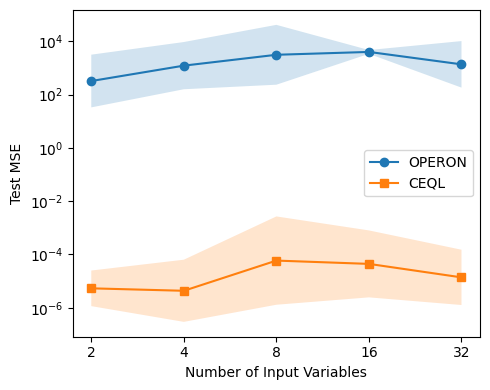

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OPERON_CSV = Path("reports/operon_scalability.csv")
CEQL_CSV = Path("reports/ceql_scalability.csv")
OUT_PDF = Path("figures/scalability.pdf")

D_MAX = 32
EPS = 1e-300

X_LABEL = "Number of Input Variables"
Y_LABEL = "Test MSE"

MARKER_OPERON = "o"
MARKER_CEQL = "s"


def load_results(path):
    df = pd.read_csv(path)
    df["d"] = df["d"].astype(int)
    df["test_mse"] = df["test_mse"].astype(float)
    return df[df["d"] <= D_MAX].copy()


def aggregate_log_band(df):
    df = df.copy()
    df["log_test_mse"] = np.log(np.maximum(df["test_mse"].to_numpy(dtype=float), EPS))

    agg = (
        df.groupby(["Expression", "d"], as_index=False)
        .agg(mu=("log_test_mse", "mean"), sigma=("log_test_mse", "std"))
        .sort_values(["Expression", "d"])
    )

    agg["sigma"] = agg["sigma"].fillna(0.0)

    mu = agg["mu"].to_numpy(dtype=float)
    sigma = agg["sigma"].to_numpy(dtype=float)

    agg["center"] = np.exp(mu)
    agg["lo"] = np.exp(mu - sigma)
    agg["hi"] = np.exp(mu + sigma)

    return agg


def uniform_x(d_vals):
    d = np.asarray(d_vals, dtype=int)
    x = np.arange(len(d), dtype=int)
    return x, [str(v) for v in d.tolist()]


def plot_joint(op, cq, expression, out_pdf):
    op = op[op["Expression"] == expression].sort_values("d")
    cq = cq[cq["Expression"] == expression].sort_values("d")

    d = np.sort(np.intersect1d(op["d"].to_numpy(dtype=int), cq["d"].to_numpy(dtype=int)))
    x, tick_labels = uniform_x(d)

    op = op.set_index("d").loc[d].reset_index()
    cq = cq.set_index("d").loc[d].reset_index()

    fig = plt.figure(figsize=(5, 4))
    ax = plt.gca()

    ax.plot(x, op["center"].to_numpy(), marker=MARKER_OPERON, label="OPERON")
    ax.fill_between(x, op["lo"].to_numpy(), op["hi"].to_numpy(), alpha=0.2)

    ax.plot(x, cq["center"].to_numpy(), marker=MARKER_CEQL, label="CEQL")
    ax.fill_between(x, cq["lo"].to_numpy(), cq["hi"].to_numpy(), alpha=0.2)

    ax.set_yscale("log")
    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(Y_LABEL)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels)
    ax.legend()

    fig.tight_layout()
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()


def main():
    op_raw = load_results(OPERON_CSV)
    cq_raw = load_results(CEQL_CSV)

    op_agg = aggregate_log_band(op_raw)
    cq_agg = aggregate_log_band(cq_raw)

    expressions = sorted(set(op_agg["Expression"].unique()) & set(cq_agg["Expression"].unique()))
    for expr in expressions:
        plot_joint(op_agg, cq_agg, expression=expr, out_pdf=OUT_PDF)


if __name__ == "__main__":
    main()
